## Сравнительный анализ методов прогнозирования цен акций на фондовых рынках Беларуси, России, мира


In [434]:
import numpy as np
import pandas as pd
import yfinance as yfin
import matplotlib.pyplot as plt
import torch
import random
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error
import xgboost as xgb


np.random.seed(42)
random.seed(42)
torch.manual_seed(42)


Prior_data = pd.read_excel("Prior_stocks.xlsx")
Sber_data = pd.read_csv("SBER_D1.csv")
Apple_data = yfin.download("AAPL",  start="2023-04-25", end="2026-04-25", interval="1d")

display(Prior_data.head())
display(Sber_data.head())
display(Apple_data.head())

[*********************100%***********************]  1 of 1 completed


,Тикер,Краткое наименование эмитента,Валюта ценообразования,"Цена, вал.обр. (мин.)","Цена, вал.обр. (макс.)","Цена, вал.обр. (срвз.)","Доходность (мин., %)","Доходность (макс., %)","Доходность (срвз., %)",Оборот (в вал.ценообр.),Оборот (в шт.),Количество сделок,Срок,Дата сделки
0,T0146-S0012,"""Приорбанк"" ОАО",BYN,4.43,4.5,4.448281,0,0,0,284.69,64,4,NaN,2025-04-01
1,T0146-S0012,"""Приорбанк"" ОАО",BYN,4.43,4.5,4.431520,0,0,0,2069.52,467,3,NaN,2025-04-02
2,T0146-S0012,"""Приорбанк"" ОАО",BYN,4.49,4.5,4.499701,0,0,0,301.48,67,3,NaN,2025-04-03
3,T0146-S0012,"""Приорбанк"" ОАО",BYN,4.50,4.5,4.500000,0,0,0,243.00,54,2,NaN,2025-04-04
4,T0146-S0012,"""Приорбанк"" ОАО",BYN,4.49,4.5,4.496226,0,0,0,238.30,53,4,NaN,2025-04-07


,datetime,open,high,low,close,volume
0,1999-06-01,0.54,0.54,0.53,0.53,778
1,1999-06-02,0.53,0.53,0.49,0.50,1926
2,1999-06-03,0.49,0.54,0.49,0.53,3346
3,1999-06-04,0.54,0.55,0.53,0.55,4694
4,1999-06-07,0.55,0.57,0.55,0.56,3505


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-04-25,161.431320,163.935042,161.391883,162.831040,48714100
2023-04-26,161.421448,162.919746,160.475165,160.731447,45498800
2023-04-27,166.005081,166.152933,162.831062,162.831062,64902300
2023-04-28,167.256912,167.424498,165.482629,166.083918,55275900
2023-05-01,167.168198,168.015917,166.231767,166.862627,52472900


# 1. EDA & Feature engineering

In [435]:
display(Prior_data.describe())
display(Sber_data.describe())
display(Apple_data.describe())

,"Цена, вал.обр. (мин.)","Цена, вал.обр. (макс.)","Цена, вал.обр. (срвз.)","Доходность (мин., %)","Доходность (макс., %)","Доходность (срвз., %)",Оборот (в вал.ценообр.),Оборот (в шт.),Количество сделок,Срок,Дата сделки
count,260.000000,260.000000,260.000000,260.0,260.0,260.0,260.000000,260.000000,260.000000,0.0,260
mean,5.367500,5.629885,5.511514,0.0,0.0,0.0,2851.360423,510.388462,5.342308,NaN,2025-10-14 06:33:13.846153
min,4.000000,4.200000,4.200000,0.0,0.0,0.0,4.500000,1.000000,1.000000,NaN,2025-04-01 00:00:00
25%,4.885000,5.032500,5.000000,0.0,0.0,0.0,153.062500,28.000000,3.000000,NaN,2025-07-10 12:00:00
50%,5.085000,5.300000,5.213750,0.0,0.0,0.0,433.525000,74.500000,5.000000,NaN,2025-10-13 12:00:00
75%,5.492500,5.892500,5.602593,0.0,0.0,0.0,2150.340000,367.500000,7.000000,NaN,2026-01-22 06:00:00
max,9.200000,9.240000,9.224328,0.0,0.0,0.0,57587.610000,11707.000000,23.000000,NaN,2026-04-25 00:00:00
std,1.037535,1.066302,1.044771,0.0,0.0,0.0,7114.063770,1279.624860,3.451000,NaN,NaN


,open,high,low,close,volume
count,6293.000000,6293.000000,6293.000000,6293.000000,6.293000e+03
mean,107.320801,108.637314,105.887227,107.314025,8.098579e+06
std,92.685132,93.564934,91.682043,92.668463,1.230617e+07
min,0.490000,0.530000,0.490000,0.500000,7.780000e+02
25%,21.000000,21.340000,20.520000,20.990000,2.981900e+04
50%,89.210000,90.600000,87.990000,89.390000,4.720310e+06
75%,169.670000,170.690000,167.140000,169.050000,1.007048e+07
max,385.900000,388.110000,376.720000,387.600000,1.642062e+08


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,753.000000,753.000000,753.000000,753.000000,7.530000e+02
mean,214.080635,216.062469,211.933366,213.909585,5.491018e+07
std,33.115461,33.464796,32.724060,33.134335,2.436518e+07
min,161.421448,162.919746,160.475165,160.731447,1.791060e+07
25%,184.938751,186.502538,182.620280,184.938783,4.196060e+07
50%,212.283997,214.216361,209.678353,211.732449,4.934030e+07
75%,238.288315,240.860913,235.921239,238.515388,6.027520e+07
max,285.922455,288.350192,283.035157,285.932471,3.186799e+08


In [436]:
Prior_to_drop = ["Доходность (мин., %)","Доходность (макс., %)", "Доходность (срвз., %)", "Срок","Количество сделок", "Оборот (в вал.ценообр.)", "Тикер", "Краткое наименование эмитента", "Валюта ценообразования" ]
Prior_data = Prior_data.drop(columns=Prior_to_drop)

Prior_col_names = {
    Prior_data.columns[0]: "Low",
    Prior_data.columns[1]: "High",
    Prior_data.columns[2]: "VWAP",
    Prior_data.columns[3]: "Volume",
    Prior_data.columns[4]: "Date",
    
}
Prior_data = Prior_data.rename(columns=Prior_col_names)
Sber_col_names = {
    Sber_data.columns[0]: "Date",
    Sber_data.columns[1]: "Open",
    Sber_data.columns[2]: "High",
    Sber_data.columns[3]: "Low",
    Sber_data.columns[4]: "Close",
    Sber_data.columns[5]: "Volume"
}
Sber_data = Sber_data.rename(columns=Sber_col_names)
Sber_data["Date"] = pd.to_datetime(Sber_data["Date"])
Sber_data = Sber_data[Sber_data["Date"] >= "2021-04-25"].reset_index(drop=True)
display(Prior_data.head())
display(Sber_data.tail())


,Low,High,VWAP,Volume,Date
0,4.43,4.5,4.448281,64,2025-04-01
1,4.43,4.5,4.431520,467,2025-04-02
2,4.49,4.5,4.499701,67,2025-04-03
3,4.50,4.5,4.500000,54,2025-04-04
4,4.49,4.5,4.496226,53,2025-04-07


,Date,Open,High,Low,Close,Volume
826,2024-08-21,266.16,267.80,263.86,266.93,3708836
827,2024-08-22,266.93,268.50,260.15,261.60,4783843
828,2024-08-23,261.70,262.80,255.56,259.50,7669263
829,2024-08-26,263.55,266.95,261.54,265.39,4974413
830,2024-08-27,265.82,266.07,259.82,260.50,3232464


In [437]:
Apple_data.columns = Apple_data.columns.get_level_values(0)
Apple_data = Apple_data.reset_index()
typical_prices = {}

datasets = {
    "Apple_data": Apple_data,
    "Prior_data": Prior_data,
    "Sber_data": Sber_data,
}
for name, dataset in datasets.items():
    dataset_Price = dataset["VWAP"] if name == "Prior_data" else dataset["Close"]

    dataset["Typical Price"] = (dataset["Low"] + dataset["High"] + dataset_Price)/3
    dataset["Log Returns"] = np.log(dataset_Price / dataset_Price.shift(1))
    dataset["Volatility"] = dataset["Log Returns"].rolling(window=20).std()
    dataset["10-day SMA"] = dataset_Price.rolling(window=10).mean()
    delta = dataset_Price.diff()
    dataset["RSI"] = 100 - 100 / (1 + delta.where(delta>0,0).rolling(14).mean() / (-delta.where(delta<0,0)).rolling(14).mean())
    dataset["Volume_Change"] = dataset["Volume"].pct_change()
    dataset["Target"] = dataset["Typical Price"].shift(-1)
    typical_prices[name] = dataset["Typical Price"].copy() 
    dataset = dataset.dropna().reset_index(drop=True)
    dataset = dataset.drop(columns=["High","Low","Typical Price", "Date", "Volume"])
    if name == "Prior_data":
        dataset = dataset.drop(columns=["VWAP"])
    else:
        dataset = dataset.drop(columns=["Open", "Close"])
    datasets[name] = dataset
    

Prior_data = datasets["Prior_data"]
Sber_data = datasets["Sber_data"]
Apple_data = datasets["Apple_data"]

display(Prior_data.tail())
display(Sber_data.tail())
display(Apple_data.tail())

,Log Returns,Volatility,10-day SMA,RSI,Volume_Change,Target
234,0.001851,0.029803,8.565267,86.340073,-0.966202,9.200000
235,0.025888,0.029389,8.674371,84.806340,-0.900763,9.221443
236,0.002641,0.029495,8.781755,81.966199,9.307692,9.049344
237,-0.022618,0.030382,8.828558,73.628425,-0.089552,9.066458
238,0.010078,0.028967,8.920426,76.811207,-0.475410,9.122361


,Log Returns,Volatility,10-day SMA,RSI,Volume_Change,Target
805,-0.007373,0.013057,277.669,23.497017,-0.209286,266.196667
806,0.002739,0.012999,276.142,25.982946,-0.315802,263.416667
807,-0.020170,0.013292,274.193,23.652436,0.289850,259.286667
808,-0.008060,0.013264,271.999,28.921698,0.603159,264.626667
809,0.022444,0.014074,270.464,32.448008,-0.351383,262.130000


Price,Log Returns,Volatility,10-day SMA,RSI,Volume_Change,Target
727,0.025600,0.014156,261.031998,73.359513,0.418093,272.539998
728,0.010381,0.014091,262.450998,78.396396,-0.404420,268.123332
729,-0.025520,0.015441,263.717999,63.386716,0.372220,271.260000
730,0.025959,0.016266,265.145001,67.062287,-0.138630,273.616659
731,0.000951,0.016282,266.439001,67.043043,-0.227741,271.256663


# 2. Data splitting

In [438]:
def split_time_series(data, target_col, train_size=0.8):
    X = data.drop(columns=[target_col])
    y = data[target_col]
    
    split_point = int(len(data) * train_size)
    
    X_train = X.iloc[:split_point]
    X_test = X.iloc[split_point:]
    y_train = y.iloc[:split_point]
    y_test = y.iloc[split_point:]
    
    return X_train, X_test, y_train, y_test


# 3. Recursive Boosting Class

In [ ]:
class MyRecursiveBoost:
    def __init__(self, n=400, learning_rate=0.05, subsample_size = 0.8, colsample_bytree = 0.8, depth=7, seed=42) -> None:
        self.n = n
        self.learning_rate = learning_rate
        self.depth = depth
        self.seed = seed
        self.trees = []
        self.tree_features = []
        self.importances = []
        self.subsample_size = subsample_size
        self.colsample_bytree = colsample_bytree
        
    def fit(self, X, y):
        X = X.copy()
        self.train_prices = y.copy()
        y_returns = y.pct_change().bfill()

        X["Previous Return"] = y.shift(1).bfill() 
        X = self._encode_categoricals(X, fit=True)
        self.initial_leaf = y_returns.mean()
        self.last_train_target = y.iloc[-1]
        predictions = np.zeros(len(y_returns)) +self.initial_leaf
        self.n_features_ = X.shape[1]

        for _ in range (self.n):
            X_sub, _, indices = self.subsample(X, y_returns)
            X_sub_cols, chosen_cols = self.colsubsample(X_sub)
            self.tree_features.append(chosen_cols)

            antigrad = y_returns.values - predictions
            antigrad_sub = antigrad[indices]
            tree = DecisionTreeRegressor(max_depth=self.depth, random_state=self.seed, criterion = 'friedman_mse')
            tree.fit(X_sub_cols, antigrad_sub)
            self.trees.append(tree)
            importance = tree.feature_importances_
            self.importances.append(importance)
            predictions += tree.predict(X.iloc[:, chosen_cols]) * self.learning_rate


    def predict(self, samples):
        samples = samples.copy()
        samples = self._encode_categoricals(samples, fit=False)
        
        predictions = []

        previous_price = self.last_train_target
        previous_return = 0.0
        for i in range(len(samples)):
            row = samples.iloc[i:i+1].copy()
            row["Previous Return"] = previous_return

            predicted_return = self.initial_leaf
            for j in range (self.n):
                cols = self.tree_features[j]
                predicted_return += self.learning_rate * self.trees[j].predict(row.iloc[:, cols])[0]
            prediction = previous_price * (1+ predicted_return)
            predictions.append(prediction)
            previous_price = prediction
            previous_return = predicted_return
        return np.array(predictions)
    
    def subsample(self, X, y):
        size = int(self.subsample_size * X.shape[0])
        indices = np.random.choice(X.shape[0], size, replace=False)
        X_subsample = X.iloc[indices]
        y_subsample = y[indices]
        return X_subsample, y_subsample, indices
    def colsubsample(self,X):
        n_cols = int(self.colsample_bytree * len(range(X.shape[1])))
        chosen_cols = np.random.choice( X.shape[1], n_cols, replace=False)
        X_subsample_cols = X.iloc[:, chosen_cols]
        return X_subsample_cols, chosen_cols

    def feature_importances_(self):
        result = np.zeros(self.n_features_)

        for i in range(len(self.trees)):
            imp = self.importances[i]
            cols = self.tree_features[i]
            for j in range(len(cols)):
                result[cols[j]] += imp[j]

        result /= len(self.trees)

        total = result.sum()
        if total != 0:
            result /= total

        return result
    def _encode_categoricals(self, X, fit=False):
        X_encoded = X.copy()
        cat_cols = X_encoded.select_dtypes(include=['object', 'category']).columns

        if fit:
            self.cat_columns = list(cat_cols)
            self.cat_categories = {}
            for col in self.cat_columns:
                self.cat_categories[col] = list(X_encoded[col].unique())

        for col in self.cat_columns:
            for cat in self.cat_categories[col]:
                X_encoded[col + '_' + str(cat)] = (X_encoded[col] == cat).astype(int)
            X_encoded = X_encoded.drop(columns=[col])

        return X_encoded

# 4. Mean Directional accuracy 

In [440]:
def mean_directional_accuracy(y_actual, y_pred):
    actual_direction = np.sign(np.diff(y_actual))
    predicted_direction = np.sign(np.diff(y_pred))
    
    return np.mean(actual_direction == predicted_direction)

# 5. Classic ML Pipeline

In [ ]:
results = []
models_predictions = {}

MAX_TREES = 150

models = {
    "Random Forest": RandomForestRegressor(n_estimators=MAX_TREES, max_depth=7, random_state=42),
    "RecursiveBoost": MyRecursiveBoost(n=MAX_TREES),
    "XGBoost": xgb.XGBRegressor(n_estimators=MAX_TREES,max_depth=7, learning_rate=0.05, random_state=42),
}

for name, data in datasets.items():
    X_train, X_test, y_train, y_test = split_time_series(data, "Target")

    for model_name, model in models.items():
        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        mape = mean_absolute_percentage_error(y_test, predictions)
        mda = mean_directional_accuracy(y_test, predictions)

        results.append({
            'Dataset': name,
            'Model': model_name,
            'MAPE': mape,
            'MDA': mda
        })
        models_predictions[(name, model_name)] = {
            "y_test": y_test.values,
            "predictions": predictions
        }
        

Train MAPE: 1.9512
Train MAPE: 5.6637
Train MAPE: 7.5104


# 6. LSTM

In [442]:
import os
os.environ["KERAS_BACKEND"] = "torch"

from keras.models import Sequential
from keras.layers import LSTM, Dense

lookback = 15
n_features = 5


def create_sequences(X, y, lookback=15):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


for name, data in datasets.items():
    X_train, X_test, y_train, y_test = split_time_series(data, "Target")

    scaler_X = MinMaxScaler()

    X_train = scaler_X.fit_transform(X_train)
    X_test = scaler_X.transform(X_test)

    scaler_y = MinMaxScaler()

    y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

    X_train_seq, y_train_seq = create_sequences(X_train, y_train, lookback)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test,lookback)

    model = Sequential([
        LSTM(50, input_shape=(lookback, n_features)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=16, verbose=0)

    predictions_scaled = model.predict(X_test_seq).flatten()
    predictions = scaler_y.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
    y_test_real = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    mape = mean_absolute_percentage_error(y_test_real, predictions)
    mda = mean_directional_accuracy(y_test_real, predictions)

    results.append({
        'Dataset': name,
        'Model': "LSTM",
        'MAPE': mape,
        'MDA': mda
    })
    models_predictions[(name, "LSTM")] = {
        "y_test": y_test_real,
        "predictions": predictions
    }


c:\Scientific works\ML_Stock_Prediction_In_Different_Markets\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


c:\Scientific works\ML_Stock_Prediction_In_Different_Markets\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


c:\Scientific works\ML_Stock_Prediction_In_Different_Markets\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


# 7. MDA for SMA Crossover

In [443]:
def SMA_crossover(Price_series, short_window=10, long_period=50):
    SMA_short = Price_series.rolling(window=short_window).mean()
    SMA_long = Price_series.rolling(window=long_period).mean()
    prediction = np.where(SMA_short >= SMA_long, 1, -1)
    return prediction

for name, data in datasets.items():
    Typical = typical_prices[name]
    y = data["Target"]
    pred_direction = pd.Series(SMA_crossover(Typical))
    actual_direction = np.sign(Typical.diff()).values

    MDA_SMA_crossover = (actual_direction == pred_direction).dropna().mean()
    results.append({
            'Dataset': name,
            'Model': "SMA Crossover",
            'MAPE': "-",
            'MDA': MDA_SMA_crossover
        })



# 8. Analysis

In [444]:
df_results = pd.DataFrame(results)
df_results["MAPE"] = pd.to_numeric(df_results["MAPE"], errors="coerce").round(4)
df_results["MDA"] = df_results["MDA"].astype(float).round(4)

mape_table = df_results.pivot(index="Dataset", columns="Model", values="MAPE")
mda_table = df_results.pivot(index="Dataset", columns="Model", values="MDA")

display(mape_table)
print("\n")
display(mda_table)

Model,LSTM,Random Forest,RecursiveBoost,SMA Crossover,XGBoost
Dataset,,,,,
Apple_data,0.0485,0.0775,0.1561,NaN,0.0772
Prior_data,0.1086,0.2251,0.3746,NaN,0.2293
Sber_data,0.0176,0.0202,0.2110,NaN,0.0203


Model,LSTM,Random Forest,RecursiveBoost,SMA Crossover,XGBoost
Dataset,,,,,
Apple_data,0.5420,0.5342,0.6507,0.4847,0.5616
Prior_data,0.5625,0.5106,0.5745,0.4885,0.5106
Sber_data,0.4726,0.6025,0.5342,0.5283,0.6273


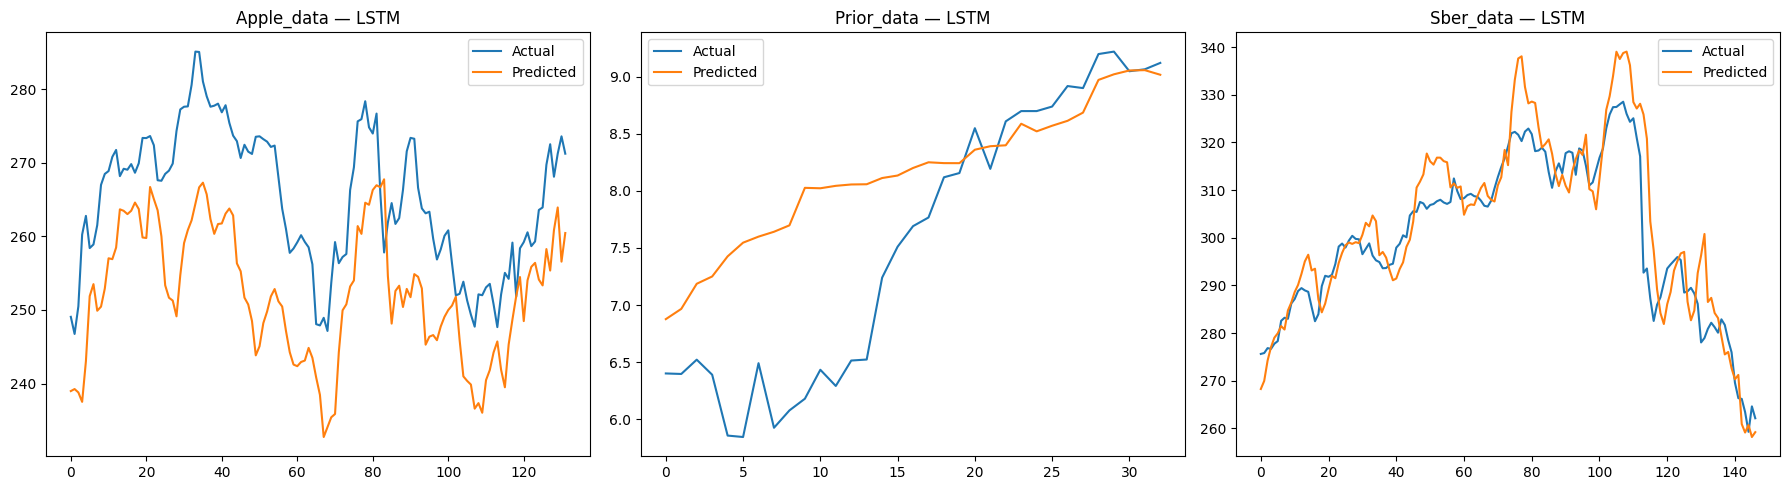

In [445]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
best_models = {"Apple_data": "LSTM", "Prior_data": "LSTM", "Sber_data": "LSTM"}

for i, (dataset_name, model_name) in enumerate(best_models.items()):
    data = models_predictions[(dataset_name, model_name)]
    axes[i].plot(data["y_test"], label="Actual")
    axes[i].plot(data["predictions"], label="Predicted")
    axes[i].set_title(f"{dataset_name} — {model_name}")
    axes[i].legend()

plt.tight_layout()
plt.show()

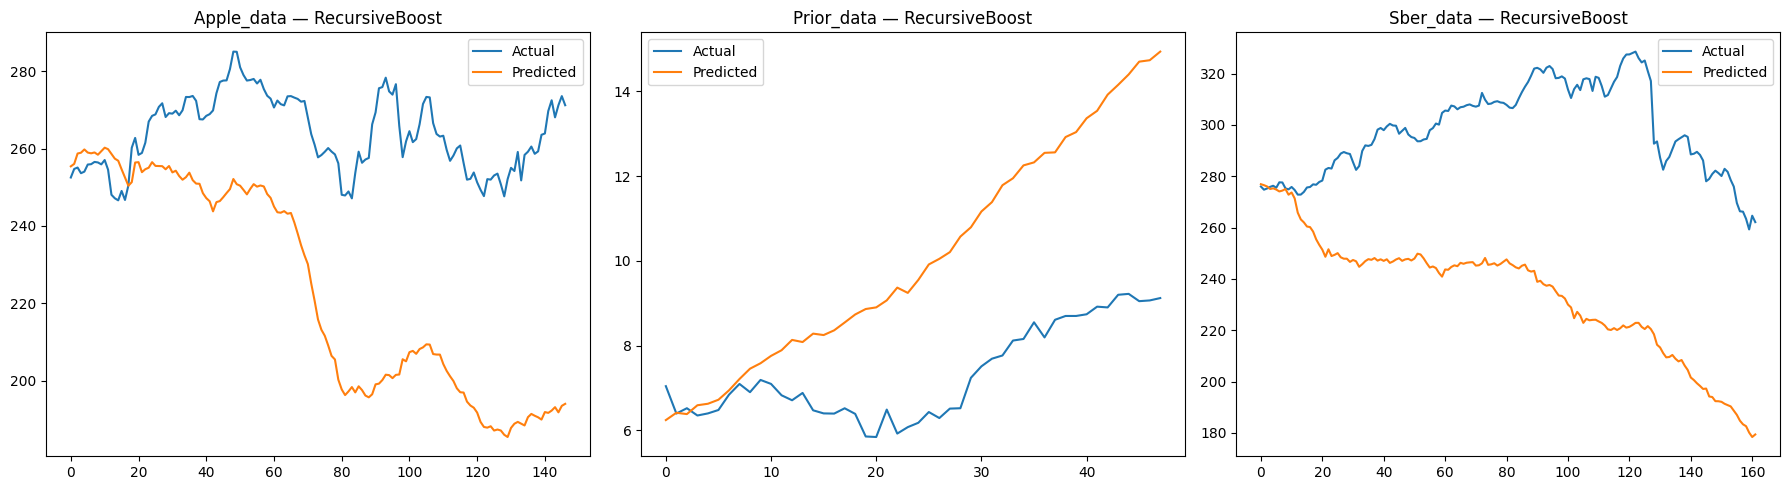

In [446]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
recursive_models = {"Apple_data": "RecursiveBoost", "Prior_data": "RecursiveBoost", "Sber_data": "RecursiveBoost"}
for i, (dataset_name, model_name) in enumerate(recursive_models.items()):
    data = models_predictions[(dataset_name, model_name)]
    axes[i].plot(data["y_test"], label="Actual")
    axes[i].plot(data["predictions"], label="Predicted")
    axes[i].set_title(f"{dataset_name} — {model_name}")
    axes[i].legend()

plt.tight_layout()
plt.show()

Day 1 pred: 6.242266244448911 actual: 7.042816901333334
Day 10 pred: 7.5836845225125975 actual: 7.19
Day 30 pred: 10.79282682344536 actual: 7.240201592000001
